# Summarize Results with Plots

In [35]:
# Uncomment below line if you are just trying to run this notebook and have not done a full installation of this project
# !pip install pandas==2.2.3 matplotlib==3.9.3 seaborn==0.13.2 tiktoken==0.8.0 numpy==2.0.1

#### Load libraries

In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken

#### Set seaborn plotting settings

In [37]:
sns.set_palette("Greys")
sns.set_context("paper")
sns.set_style("whitegrid")

## Load results dataframe

#### Set up mappings and types for neater presentation and easier sorting of results

In [38]:
path_to_results_gpt_4o = "../Data/3-Results/marked_results-compiled_gpt_4o_removed_bad_run.csv"
path_to_results_gpt_5_mini = "../Data/3-Results/marked_results-compiled_gpt_5_mini_duped_runs.csv"

mapping_prompt_names = {
    'v0_baseline': "NoContext",
    'v2a_baseline_and_provide_readme': "README",
    'v2_describe_task_and_provide_readme': "README+BugDescriptions",
    'v3a_describe_task_and_provide_readme_plus_mock_verified_sample': "AllContextExceptAssets",
    'v5_describe_task_and_provide_readme_plus_mock_verified_sample_plus_assets': "AllContext"
}
# Drop some strategies -- these results aren't very meaningful -- not useful for paper
list_names_strategies_drop = [
    "v1_describe_task",
    "v3_describe_task_and_provide_readme_plus_verified_sample",
    "v4_describe_task_and_provide_readme_plus_assets"
]
# Drop the 0th "run", from ~August 16, 2024. Despite specifying the same model snapshot, 
# it is hard to ensure/know we actually used the same model under-the-hood months apart 
# (runs 1,2,3,4 are from the same day, 6th October 2024)
list_numbers_of_runs_drop = [
    
]
# for sorting
type_prompt_strategy = pd.CategoricalDtype(categories=['NoContext', 'README', 'README+BugDescriptions', 'AllContextExceptAssets', 'AllContext'], ordered=True)
type_sample = pd.CategoricalDtype(categories=['clean', 'bug_state', 'bug_rendering', 'bug_layout', 'bug_appearance'], ordered=True)
type_app_name = pd.CategoricalDtype(
    categories=[
        "Aidymouse-Hexfriend",
        "aldy-san-zero-neko",
        "chase-manning-react-photo-studio",
        "coderetreat-coderetreat.org",
        "dimforge-rapier.js",
        "equinor-esv-intersection",
        "getkey-ble",
        "ha-shine-wasm-tetris",
        "higlass-higlass",
        "mehanix-arcada",
        "MichaelMakesGames-reflector",
        "ourcade-ecs-dependency-injection",
        "p5aholic-playground",
        "PrefectHQ-graphs",
        "solaris-games-solaris",
        "starwards-starwards",
        "tulustul-ants-sandbox",
        "uia4w-uia-wafermap",
        "VoiceSpaceUnder5-VoiceSpace",
        "Zikoat-infinite-minesweeper"
    ],
    ordered=True
)

#### Function for using in pd.Series.map(lambda x: ...)

In [39]:
def map_true_false_to_one_zero(input_to_check):
    output_val = None

    if input_to_check == True:
        output_val = 1
        
    elif input_to_check == False:
        output_val = 0

    return output_val

#### Load, slice, and clean DataFrame

In [40]:
df_results_compiled_gpt_4o = pd.read_csv(path_to_results_gpt_4o, index_col=None)

for name_of_strategy_to_drop in list_names_strategies_drop:
    df_results_compiled_gpt_4o = df_results_compiled_gpt_4o[df_results_compiled_gpt_4o["TextPromptStrategy"] != name_of_strategy_to_drop].reset_index(drop=True)

for number_of_run_to_drop in list_numbers_of_runs_drop:
    df_results_compiled_gpt_4o = df_results_compiled_gpt_4o[df_results_compiled_gpt_4o["IntRunNumber"] != number_of_run_to_drop].reset_index(drop=True)

df_results_compiled_gpt_4o["TextPromptStrategy"] = df_results_compiled_gpt_4o["TextPromptStrategy"].map(lambda x: mapping_prompt_names[x])

df_results_compiled_gpt_4o['BoolScreenshotContainsVisualBug'] = df_results_compiled_gpt_4o['BoolScreenshotContainsVisualBug'].apply(map_true_false_to_one_zero)
df_results_compiled_gpt_4o['BoolDidDetectVisualBug'] = df_results_compiled_gpt_4o['BoolDidDetectVisualBug'].apply(map_true_false_to_one_zero)
df_results_compiled_gpt_4o['BoolDescriptionIsCorrect'] = df_results_compiled_gpt_4o['BoolDescriptionIsCorrect'].apply(map_true_false_to_one_zero)

df_results_compiled_gpt_4o['IntRunNumber'] = df_results_compiled_gpt_4o['IntRunNumber'].astype(int)
df_results_compiled_gpt_4o['TextPromptStrategy'] = df_results_compiled_gpt_4o['TextPromptStrategy'].astype(type_prompt_strategy)
df_results_compiled_gpt_4o['TextAppName'] = df_results_compiled_gpt_4o['TextAppName'].astype(type_app_name)
df_results_compiled_gpt_4o['TextSampleName'] = df_results_compiled_gpt_4o['TextSampleName'].astype(type_sample)
df_results_compiled_gpt_4o['BoolScreenshotContainsVisualBug'] = df_results_compiled_gpt_4o['BoolScreenshotContainsVisualBug'].astype(int)
df_results_compiled_gpt_4o['BoolDidDetectVisualBug'] = df_results_compiled_gpt_4o['BoolDidDetectVisualBug'].astype(int)
df_results_compiled_gpt_4o['BoolDescriptionIsCorrect'] = df_results_compiled_gpt_4o['BoolDescriptionIsCorrect'].astype(int)

df_results_compiled_gpt_4o = df_results_compiled_gpt_4o[["TextPromptStrategy", "TextAppName", "TextSampleName", "IntRunNumber", "BoolScreenshotContainsVisualBug", "BoolDidDetectVisualBug", "BoolDescriptionIsCorrect"]]
df_results_compiled_gpt_4o = df_results_compiled_gpt_4o.sort_values(by=["TextPromptStrategy", "TextAppName", "TextSampleName", "IntRunNumber"]).reset_index(drop=True)

df_results_compiled_gpt_4o

df_results_compiled_gpt_5_mini = pd.read_csv(path_to_results_gpt_5_mini, index_col=None)

for name_of_strategy_to_drop in list_names_strategies_drop:
    df_results_compiled_gpt_5_mini = df_results_compiled_gpt_5_mini[df_results_compiled_gpt_5_mini["TextPromptStrategy"] != name_of_strategy_to_drop].reset_index(drop=True)

for number_of_run_to_drop in list_numbers_of_runs_drop:
    df_results_compiled_gpt_5_mini = df_results_compiled_gpt_5_mini[df_results_compiled_gpt_5_mini["IntRunNumber"] != number_of_run_to_drop].reset_index(drop=True)

df_results_compiled_gpt_5_mini["TextPromptStrategy"] = df_results_compiled_gpt_5_mini["TextPromptStrategy"].map(lambda x: mapping_prompt_names[x])

df_results_compiled_gpt_5_mini['BoolScreenshotContainsVisualBug'] = df_results_compiled_gpt_5_mini['BoolScreenshotContainsVisualBug'].apply(map_true_false_to_one_zero)
df_results_compiled_gpt_5_mini['BoolDidDetectVisualBug'] = df_results_compiled_gpt_5_mini['BoolDidDetectVisualBug'].apply(map_true_false_to_one_zero)
df_results_compiled_gpt_5_mini['BoolDescriptionIsCorrect'] = df_results_compiled_gpt_5_mini['BoolDescriptionIsCorrect'].apply(map_true_false_to_one_zero)

df_results_compiled_gpt_5_mini['IntRunNumber'] = df_results_compiled_gpt_5_mini['IntRunNumber'].astype(int)
df_results_compiled_gpt_5_mini['TextPromptStrategy'] = df_results_compiled_gpt_5_mini['TextPromptStrategy'].astype(type_prompt_strategy)
df_results_compiled_gpt_5_mini['TextAppName'] = df_results_compiled_gpt_5_mini['TextAppName'].astype(type_app_name)
df_results_compiled_gpt_5_mini['TextSampleName'] = df_results_compiled_gpt_5_mini['TextSampleName'].astype(type_sample)
df_results_compiled_gpt_5_mini['BoolScreenshotContainsVisualBug'] = df_results_compiled_gpt_5_mini['BoolScreenshotContainsVisualBug'].astype(int)
df_results_compiled_gpt_5_mini['BoolDidDetectVisualBug'] = df_results_compiled_gpt_5_mini['BoolDidDetectVisualBug'].astype(int)
df_results_compiled_gpt_5_mini['BoolDescriptionIsCorrect'] = df_results_compiled_gpt_5_mini['BoolDescriptionIsCorrect'].astype(int)

df_results_compiled_gpt_5_mini = df_results_compiled_gpt_5_mini[["TextPromptStrategy", "TextAppName", "TextSampleName", "IntRunNumber", "BoolScreenshotContainsVisualBug", "BoolDidDetectVisualBug", "BoolDescriptionIsCorrect"]]
df_results_compiled_gpt_5_mini = df_results_compiled_gpt_5_mini.sort_values(by=["TextPromptStrategy", "TextAppName", "TextSampleName", "IntRunNumber"]).reset_index(drop=True)

df_results_compiled_gpt_5_mini

,TextPromptStrategy,TextAppName,TextSampleName,IntRunNumber,BoolScreenshotContainsVisualBug,BoolDidDetectVisualBug,BoolDescriptionIsCorrect
0,NoContext,Aidymouse-Hexfriend,clean,0,0,1,0
1,NoContext,Aidymouse-Hexfriend,clean,1,0,1,0
2,NoContext,Aidymouse-Hexfriend,clean,2,0,1,0
3,NoContext,Aidymouse-Hexfriend,clean,3,0,1,0
4,NoContext,Aidymouse-Hexfriend,bug_state,0,1,1,0
...,...,...,...,...,...,...,...
1675,AllContext,Zikoat-infinite-minesweeper,bug_layout,3,1,1,1
1676,AllContext,Zikoat-infinite-minesweeper,bug_appearance,0,1,1,0
1677,AllContext,Zikoat-infinite-minesweeper,bug_appearance,1,1,1,0
1678,AllContext,Zikoat-infinite-minesweeper,bug_appearance,2,1,1,0


#### Create lists of unique values from DataFrame

In [41]:
run_numbers_gpt_4o = df_results_compiled_gpt_4o['IntRunNumber'].unique().tolist()
prompt_strategies_gpt_4o = df_results_compiled_gpt_4o['TextPromptStrategy'].unique().tolist()
app_names_gpt_4o = df_results_compiled_gpt_4o['TextAppName'].unique().tolist()
sample_names_gpt_4o = df_results_compiled_gpt_4o['TextSampleName'].unique().tolist()

run_numbers_gpt_5_mini = df_results_compiled_gpt_5_mini['IntRunNumber'].unique().tolist()
prompt_strategies_gpt_5_mini = df_results_compiled_gpt_5_mini['TextPromptStrategy'].unique().tolist()
app_names_gpt_5_mini = df_results_compiled_gpt_5_mini['TextAppName'].unique().tolist()
sample_names_gpt_5_mini = df_results_compiled_gpt_5_mini['TextSampleName'].unique().tolist()

assert run_numbers_gpt_4o == run_numbers_gpt_5_mini
assert prompt_strategies_gpt_4o == prompt_strategies_gpt_5_mini
assert app_names_gpt_4o == app_names_gpt_5_mini
assert sample_names_gpt_4o == sample_names_gpt_5_mini

run_numbers = run_numbers_gpt_4o
prompt_strategies = prompt_strategies_gpt_4o
app_names = app_names_gpt_4o
sample_names = sample_names_gpt_4o

## Define functions for use in notebook

#### Metrics function definitions

In [42]:
def get_true_positives(df):
    # (Does contain a bug) AND (did detect bug) AND (description is correct)
    return df.loc[(df["BoolScreenshotContainsVisualBug"] == 1) & (df["BoolDidDetectVisualBug"] == 1) & (df["BoolDescriptionIsCorrect"] == 1)]


def get_false_positives(df):
    # (Does not contain a bug) AND (did detect a bug)
    # OR
    # (Does contain a bug) AND (description is incorrect)
    return df.loc[
        ((df["BoolScreenshotContainsVisualBug"] == 0) & (df["BoolDidDetectVisualBug"] == 1))
        |
        ((df["BoolScreenshotContainsVisualBug"] == 1) & (df["BoolDidDetectVisualBug"] == 1) & (df["BoolDescriptionIsCorrect"] == 0))
    ]


def get_true_negatives(df):
    # (Does not contain a bug) AND (did not detect a bug)
    return df.loc[(df["BoolScreenshotContainsVisualBug"] == 0) & (df["BoolDidDetectVisualBug"] == 0)]


def get_false_negatives(df):
    # (Does contain a bug) AND (did not detect a bug)
    return df.loc[(df["BoolScreenshotContainsVisualBug"] == 1) & (df["BoolDidDetectVisualBug"] == 0)]


In [43]:
def calculate_accuracy(num_true_positives, num_true_negatives, num_false_positives, num_false_negatives):
    try:
        return ((num_true_positives + num_true_negatives) / (num_true_positives + num_true_negatives + num_false_positives + num_false_negatives))
    
    except ZeroDivisionError:
        return 0.0


def calculate_precision(num_true_positives, num_false_positives):
    try:
        return ((num_true_positives) / (num_true_positives + num_false_positives))
    
    except ZeroDivisionError:
        return 0.0


def calculate_recall(num_true_positives, num_false_negatives):
    try:
        return ((num_true_positives) / (num_true_positives + num_false_negatives))

    except ZeroDivisionError:
        return 0.0


In [44]:
# OpenAI -- Evaluating LLMs Trained on Code
def calculate_pass_at_k(n, c, k) :
    """
    :param n: total number of samples (responses generated)
    :param c: number of correct samples
    :param k: k in pass@k
    """
    if (n - c) < k: return np.float64(1.0)
    ### To inspect the calculation:
    # print("n", n, "c", c, "k", k)
    # print("n-c", n-c)
    # print(np.arange((n-c+1), (n+1)))
    # print(np.prod(1.0 - k / np.arange((n-c+1), (n+1))))
    # print(1.0 - np.prod(1.0 - k / np.arange((n-c+1), (n+1))))
    ###
    return 1.0 - np.prod(1.0 - k / np.arange(
        (n - c + 1),
        (n + 1)
    ))


def aggregate_pass_at_k_across_problems(df_pass_at_k):

    df_pass_at_k_overall = df_pass_at_k.groupby(
        "PromptingStrategy",
        dropna=False
    ).agg({
        "Pass@1": ["mean", "std"],
        "Pass@2": ["mean", "std"],
        "Pass@3": ["mean", "std"],
        "Pass@4": ["mean", "std"],
    })
    return df_pass_at_k_overall


def calculate_pass_at_k_across_repetitions(
    df_sliced_on_prompt,
    k_range=None,
    string_name_column_correct_prediction="BoolDescriptionIsCorrect",
    string_name_column_app_names="TextAppName",
    string_name_column_sample_names="TextSampleName"
):

    if k_range is None:
        k_range = [1, 2, 3, 4]

    list_of_app_names = df_sliced_on_prompt[string_name_column_app_names].unique()
    list_of_sample_names = df_sliced_on_prompt[string_name_column_sample_names].unique()
    list_of_pass_at_k_dicts = list()

    for sample_name in list_of_sample_names:

        for app_name in list_of_app_names:

            dict_record = {
                "Sample": sample_name,
                "AppName": app_name
            }

            # Calculate pass@k for each k (number of repetitions to include)
            for k in k_range:  # k

                df_this = df_sliced_on_prompt[
                    (df_sliced_on_prompt[string_name_column_sample_names] == sample_name)
                    &
                    (df_sliced_on_prompt[string_name_column_app_names] == app_name)
                ]

                is_predictions_correct = df_this[string_name_column_correct_prediction]
                count_correct = np.sum(is_predictions_correct)  # Ci
                num_responses_generated = len(is_predictions_correct)  # n

                pass_at_k_val = calculate_pass_at_k(num_responses_generated, count_correct, k)

                dict_record[f"Pass@{k}"] = pass_at_k_val

            list_of_pass_at_k_dicts.append(dict_record)

    return pd.DataFrame(list_of_pass_at_k_dicts)

#### DataFrame function definitions

In [45]:
def slice_data_for_run(df, int_of_run):
    return df.loc[df["IntRunNumber"] == int_of_run]
    
def slice_data_for_prompt(df, name_of_prompt):
    return df.loc[df["TextPromptStrategy"] == name_of_prompt]

def slice_data_for_app(df, name_of_app):
    return df.loc[df["TextAppName"] == name_of_app]

def slice_data_for_sample(df, name_of_sample):
    return df.loc[df["TextSampleName"] == name_of_sample]


In [46]:
def create_empty_dataframe(columns):
    return pd.DataFrame(columns=columns)

## Per-sample results

### Construct DataFrames for Results

#### For pass@k

In [47]:
df_pass_at_k = create_empty_dataframe(['PromptingStrategy', 'Sample', 'Pass@1', 'Pass@2', 'Pass@3', 'Pass@4'])

for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled, prompt)
    df_pass_at_k_this_prompt = calculate_pass_at_k_across_repetitions(df_for_prompt)
    df_pass_at_k_this_prompt["PromptingStrategy"] = prompt
    df_pass_at_k = pd.concat([df_pass_at_k, df_pass_at_k_this_prompt], ignore_index=True)

df_pass_at_k_overall = aggregate_pass_at_k_across_problems(df_pass_at_k)

# Ensure types for ordering
df_pass_at_k_overall.index = df_pass_at_k_overall.index.astype(type_prompt_strategy)

# Sort DataFrame
df_pass_at_k_overall = df_pass_at_k_overall.sort_values(["PromptingStrategy"])

NameError: name 'df_results_compiled' is not defined

#### For per-type metrics

In [48]:
# Create empty DataFrame to store metrics
df_metrics_per_sample_gpt_4o = create_empty_dataframe(['PromptingStrategy', 'Sample', 'Accuracy', 'Precision', 'Recall'])

for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled_gpt_4o, prompt)

    for sample in sample_names:
        df_for_prompt_with_sample = slice_data_for_sample(df_for_prompt, sample)

        # Initialize metrics dictionary
        metrics = {
            'PromptingStrategy': prompt,
            'Sample': sample,
            'Accuracy': None,
            'Precision': None,
            'Recall': None,
        }

        list_accuracies = []
        list_precisions = []
        list_recalls = []

        for run in run_numbers:
            df_for_prompt_with_sample_on_specific_run = slice_data_for_run(df_for_prompt_with_sample, run)

            num_true_positives = len(get_true_positives(df_for_prompt_with_sample_on_specific_run))
            num_true_negatives = len(get_true_negatives(df_for_prompt_with_sample_on_specific_run))
            num_false_positives = len(get_false_positives(df_for_prompt_with_sample_on_specific_run))
            num_false_negatives = len(get_false_negatives(df_for_prompt_with_sample_on_specific_run))

            float_accuracy = calculate_accuracy(
                num_true_positives,
                num_true_negatives,
                num_false_positives,
                num_false_negatives
            )
            float_precision = calculate_precision(num_true_positives, num_false_positives)
            float_recall = calculate_recall(num_true_positives, num_false_negatives)

            list_accuracies.append(float_accuracy)
            list_precisions.append(float_precision)
            list_recalls.append(float_recall)

        metrics['Accuracy'] = list_accuracies
        metrics['Precision'] = list_precisions
        metrics['Recall'] = list_recalls

        # Ensure consistent data types
        df_metrics_this_sample = pd.DataFrame([metrics])

        # Append to df_metrics_per_sample
        df_metrics_per_sample_gpt_4o = pd.concat([df_metrics_per_sample_gpt_4o, df_metrics_this_sample], ignore_index=True)

# df_metrics_per_sample_all = df_metrics_per_sample.merge(df_pass_at_k_overall, how="outer", on=["PromptingStrategy", "Sample"])

# Re-order columns
df_metrics_per_sample_gpt_4o = df_metrics_per_sample_gpt_4o[[
    "PromptingStrategy",
    "Sample",
    "Accuracy",
    "Precision",
    "Recall"
]]

# Ensure types for ordering
df_metrics_per_sample_gpt_4o["PromptingStrategy"] = df_metrics_per_sample_gpt_4o["PromptingStrategy"].astype(type_prompt_strategy)

# Sort DataFrame
df_metrics_per_sample_gpt_4o.sort_values(["PromptingStrategy", "Sample"])

# Reset index for DataFrame
df_metrics_per_sample_gpt_4o.reset_index(drop=True, inplace=True)


# Create empty DataFrame to store metrics
df_metrics_per_sample_gpt_5_mini = create_empty_dataframe(['PromptingStrategy', 'Sample', 'Accuracy', 'Precision', 'Recall'])

for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled_gpt_5_mini, prompt)

    for sample in sample_names:
        df_for_prompt_with_sample = slice_data_for_sample(df_for_prompt, sample)

        # Initialize metrics dictionary
        metrics = {
            'PromptingStrategy': prompt,
            'Sample': sample,
            'Accuracy': None,
            'Precision': None,
            'Recall': None,
        }

        list_accuracies = []
        list_precisions = []
        list_recalls = []

        for run in run_numbers:
            df_for_prompt_with_sample_on_specific_run = slice_data_for_run(df_for_prompt_with_sample, run)

            num_true_positives = len(get_true_positives(df_for_prompt_with_sample_on_specific_run))
            num_true_negatives = len(get_true_negatives(df_for_prompt_with_sample_on_specific_run))
            num_false_positives = len(get_false_positives(df_for_prompt_with_sample_on_specific_run))
            num_false_negatives = len(get_false_negatives(df_for_prompt_with_sample_on_specific_run))

            float_accuracy = calculate_accuracy(
                num_true_positives,
                num_true_negatives,
                num_false_positives,
                num_false_negatives
            )
            float_precision = calculate_precision(num_true_positives, num_false_positives)
            float_recall = calculate_recall(num_true_positives, num_false_negatives)

            list_accuracies.append(float_accuracy)
            list_precisions.append(float_precision)
            list_recalls.append(float_recall)

        metrics['Accuracy'] = list_accuracies
        metrics['Precision'] = list_precisions
        metrics['Recall'] = list_recalls

        # Ensure consistent data types
        df_metrics_this_sample = pd.DataFrame([metrics])

        # Append to df_metrics_per_sample
        df_metrics_per_sample_gpt_5_mini = pd.concat([df_metrics_per_sample_gpt_5_mini, df_metrics_this_sample], ignore_index=True)

# df_metrics_per_sample_all = df_metrics_per_sample.merge(df_pass_at_k_overall, how="outer", on=["PromptingStrategy", "Sample"])

# Re-order columns
df_metrics_per_sample_gpt_5_mini = df_metrics_per_sample_gpt_5_mini[[
    "PromptingStrategy",
    "Sample",
    "Accuracy",
    "Precision",
    "Recall"
]]

# Ensure types for ordering
df_metrics_per_sample_gpt_5_mini["PromptingStrategy"] = df_metrics_per_sample_gpt_5_mini["PromptingStrategy"].astype(type_prompt_strategy)

# Sort DataFrame
df_metrics_per_sample_gpt_5_mini.sort_values(["PromptingStrategy", "Sample"])

# Reset index for DataFrame
df_metrics_per_sample_gpt_5_mini.reset_index(drop=True, inplace=True)

#### For per-app metrics

In [49]:
# Create empty DataFrame to store metrics
df_metrics_per_app_gpt_4o = create_empty_dataframe(['PromptingStrategy', 'AppName', 'Accuracy', 'Precision', 'Recall'])
df_metrics_per_app_gpt_4o = df_metrics_per_app_gpt_4o.astype({
    'Precision': 'float',
    'Recall': 'float',
    'Accuracy': 'float'
})

for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled_gpt_4o, prompt)

    for app in app_names:
        df_for_prompt_with_sample = slice_data_for_app(df_for_prompt, app)

        # Initialize metrics dictionary
        metrics = {
            'PromptingStrategy': prompt,
            'AppName': app,
            'Accuracy': None,
            'Precision': None,
            'Recall': None
        }

        list_accuracies = []
        list_precisions = []
        list_recalls = []

        for run in run_numbers:
            df_for_prompt_with_app_on_specific_run = slice_data_for_run(df_for_prompt_with_sample, run)

            num_true_positives = len(get_true_positives(df_for_prompt_with_app_on_specific_run))
            num_true_negatives = len(get_true_negatives(df_for_prompt_with_app_on_specific_run))
            num_false_positives = len(get_false_positives(df_for_prompt_with_app_on_specific_run))
            num_false_negatives = len(get_false_negatives(df_for_prompt_with_app_on_specific_run))

            float_accuracy = calculate_accuracy(
                num_true_positives,
                num_true_negatives,
                num_false_positives,
                num_false_negatives
            )
            float_precision = calculate_precision(num_true_positives, num_false_positives)
            float_recall = calculate_recall(num_true_positives, num_false_negatives)

            list_accuracies.append(float_accuracy)
            list_precisions.append(float_precision)
            list_recalls.append(float_recall)

        metrics['Accuracy'] = list_accuracies
        metrics['Precision'] = list_precisions
        metrics['Recall'] = list_recalls

        # Ensure consistent data types
        df_metrics_this_sample = pd.DataFrame([metrics])

        df_metrics_per_app_gpt_4o = pd.concat([df_metrics_per_app_gpt_4o, df_metrics_this_sample], ignore_index=True)

# Re-order columns
df_metrics_per_app_gpt_4o = df_metrics_per_app_gpt_4o[[
    "PromptingStrategy",
    "AppName",
    "Accuracy",
    "Precision",
    "Recall",
]]

# Ensure types for ordering
df_metrics_per_app_gpt_4o["PromptingStrategy"] = df_metrics_per_app_gpt_4o["PromptingStrategy"].astype(type_prompt_strategy)

# Sort DataFrame
df_metrics_per_app_gpt_4o.sort_values(["PromptingStrategy", "AppName"])

# Reset index for DataFrame
df_metrics_per_app_gpt_4o.reset_index(drop=True, inplace=True)


# Create empty DataFrame to store metrics
df_metrics_per_app_gpt_5_mini = create_empty_dataframe(['PromptingStrategy', 'AppName', 'Accuracy', 'Precision', 'Recall'])
df_metrics_per_app_gpt_5_mini = df_metrics_per_app_gpt_5_mini.astype({
    'Precision': 'float',
    'Recall': 'float',
    'Accuracy': 'float'
})

for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled_gpt_5_mini, prompt)

    for app in app_names:
        df_for_prompt_with_sample = slice_data_for_app(df_for_prompt, app)

        # Initialize metrics dictionary
        metrics = {
            'PromptingStrategy': prompt,
            'AppName': app,
            'Accuracy': None,
            'Precision': None,
            'Recall': None
        }

        list_accuracies = []
        list_precisions = []
        list_recalls = []

        for run in run_numbers:
            df_for_prompt_with_app_on_specific_run = slice_data_for_run(df_for_prompt_with_sample, run)

            num_true_positives = len(get_true_positives(df_for_prompt_with_app_on_specific_run))
            num_true_negatives = len(get_true_negatives(df_for_prompt_with_app_on_specific_run))
            num_false_positives = len(get_false_positives(df_for_prompt_with_app_on_specific_run))
            num_false_negatives = len(get_false_negatives(df_for_prompt_with_app_on_specific_run))

            float_accuracy = calculate_accuracy(
                num_true_positives,
                num_true_negatives,
                num_false_positives,
                num_false_negatives
            )
            float_precision = calculate_precision(num_true_positives, num_false_positives)
            float_recall = calculate_recall(num_true_positives, num_false_negatives)

            list_accuracies.append(float_accuracy)
            list_precisions.append(float_precision)
            list_recalls.append(float_recall)

        metrics['Accuracy'] = list_accuracies
        metrics['Precision'] = list_precisions
        metrics['Recall'] = list_recalls

        # Ensure consistent data types
        df_metrics_this_sample = pd.DataFrame([metrics])

        df_metrics_per_app_gpt_5_mini = pd.concat([df_metrics_per_app_gpt_5_mini, df_metrics_this_sample], ignore_index=True)

# Re-order columns
df_metrics_per_app_gpt_5_mini = df_metrics_per_app_gpt_5_mini[[
    "PromptingStrategy",
    "AppName",
    "Accuracy",
    "Precision",
    "Recall",
]]

# Ensure types for ordering
df_metrics_per_app_gpt_5_mini["PromptingStrategy"] = df_metrics_per_app_gpt_5_mini["PromptingStrategy"].astype(type_prompt_strategy)

# Sort DataFrame
df_metrics_per_app_gpt_5_mini.sort_values(["PromptingStrategy", "AppName"])

# Reset index for DataFrame
df_metrics_per_app_gpt_5_mini.reset_index(drop=True, inplace=True)

### Overall accuracy

In [50]:
for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled_gpt_4o, prompt)

    num_true_positives = len(get_true_positives(df_for_prompt))
    num_true_negatives = len(get_true_negatives(df_for_prompt))
    num_false_positives = len(get_false_positives(df_for_prompt))
    num_false_negatives = len(get_false_negatives(df_for_prompt))

    float_accuracy = calculate_accuracy(
        num_true_positives,
        num_true_negatives,
        num_false_positives,
        num_false_negatives
    )

    print(prompt, float_accuracy)

print("")

for prompt in prompt_strategies:
    df_for_prompt = slice_data_for_prompt(df_results_compiled_gpt_5_mini, prompt)

    num_true_positives = len(get_true_positives(df_for_prompt))
    num_true_negatives = len(get_true_negatives(df_for_prompt))
    num_false_positives = len(get_false_positives(df_for_prompt))
    num_false_negatives = len(get_false_negatives(df_for_prompt))

    float_accuracy = calculate_accuracy(
        num_true_positives,
        num_true_negatives,
        num_false_positives,
        num_false_negatives
    )

    print(prompt, float_accuracy)

NoContext 0.255
README 0.29
README+BugDescriptions 0.255
AllContextExceptAssets 0.385
AllContext 0.32272727272727275

NoContext 0.17
README 0.2111111111111111
README+BugDescriptions 0.23333333333333334
AllContextExceptAssets 0.5388888888888889
AllContext 0.44


In [51]:
#df_metrics_per_app_exploded = df_metrics_per_app.explode(["Accuracy", "Precision", "Recall"])
#df_metrics_per_app_exploded.groupby("PromptingStrategy")[["Accuracy", "Precision", "Recall"]].agg(["mean", "std"])

In [52]:
# df_metrics_per_app_exploded.groupby("PromptingStrategy").plot(kind="box", y="Accuracy", color="blue")

### View results in tables

In [53]:
# df_pass_at_k[df_pass_at_k["PromptingStrategy"] == "AllContextExceptAssets"]

In [54]:
# df_pass_at_k[df_pass_at_k["PromptingStrategy"] == "NoContext"]["Pass@1"].size

In [55]:
# df_pass_at_k[df_pass_at_k["PromptingStrategy"] == "AllContext"]["Pass@1"].size

In [56]:
# df_pass_at_k[
#     (df_pass_at_k["PromptingStrategy"] == "NoContext")
#     &
#     (df_pass_at_k["Sample"] == "bug_rendering")
# ]

In [57]:
# df_pass_at_k_overall

In [58]:
# df_metrics_per_sample

In [59]:
# df_metrics_per_app

In [60]:
# inspect more
#df_metrics_per_app_exploded = df_metrics_per_app.explode(["Accuracy", "Precision", "Recall"])
#df_metrics_per_app_for_best_strategy = df_metrics_per_app_exploded[df_metrics_per_app_exploded["PromptingStrategy"] == "AllContextExceptAssets"]

In [61]:
#df_metrics_per_app_for_best_strategy

In [62]:
# (df_metrics_per_app_for_best_strategy.groupby(["PromptingStrategy", "AppName"], observed=True)[["Precision", "Recall"]].median() * 100).round(0)

In [63]:
# (df_metrics_per_app_for_best_strategy.groupby("PromptingStrategy", observed=True)[["Precision", "Recall"]].median() * 100).round(0)

In [64]:
# df_metrics_per_app_for_best_strategy[df_metrics_per_app_for_best_strategy["Recall"] == df_metrics_per_app_for_best_strategy["Recall"].max()]

In [65]:
#df_metrics_per_app_for_best_strategy[df_metrics_per_app_for_best_strategy["Accuracy"] == df_metrics_per_app_for_best_strategy["Accuracy"].max()]

### Sanity check some results

#### Check 1 - Precision is 100% for "AllContextExceptAssets" with "bug_appearance" and "bug_layout"

In [66]:
#df_metrics_per_sample[(df_metrics_per_sample["PromptingStrategy"] == "AllContextExceptAssets") & (df_metrics_per_sample["Sample"] == "bug_appearance")]

*Check there is 0 FP in the original DF*

In [67]:
# Correct
#get_false_positives(df_results_compiled[(df_results_compiled["TextPromptStrategy"] == "AllContextExceptAssets") & (df_results_compiled["TextSampleName"] == "bug_appearance")])

#### Check 2 - Bug-free Accuracy is high (94%) for "README+BugDescriptions"

In [68]:
#df_metrics_per_sample[(df_metrics_per_sample["PromptingStrategy"] == "README+BugDescriptions") & (df_metrics_per_sample["Sample"] == "clean")]

*Check there is 1 FP for Run 2, 1 FP for Run 3, 0 FP for Run 4, and 3 FP for Run 5 in the original DF*

In [69]:
# Correct
#get_false_positives(df_results_compiled[(df_results_compiled["TextPromptStrategy"] == "README+BugDescriptions") & (df_results_compiled["TextSampleName"] == "clean")])

###  Create LaTeX table for pass@k

In [ ]:
#(df_pass_at_k_overall_rounded := (df_pass_at_k_overall).apply(lambda x: np.round(x, 5)))

NameError: name 'df_pass_at_k_overall' is not defined

In [72]:
def round_with_halves_ceiled(series):
    return series.apply(lambda x: np.floor(x + 0.5) if x > 0 else np.ceil((x - 0.5)))

#(df_pass_at_k_overall_rounded := (100 * df_pass_at_k_overall).apply(round_with_halves_ceiled))

In [73]:
# line_header_1 = " & \\multicolumn{2}{l}{\\textbf{Pass@1}} & \\multicolumn{2}{l}{\\textbf{Pass@2}} & \\multicolumn{2}{l}{\\textbf{Pass@3}} & \\multicolumn{2}{l}{\\textbf{Pass@4}} \\\\"
line_header_1 = " & \\multicolumn{2}{l}{\\textbf{Pass@1}} & \\multicolumn{2}{l}{\\textbf{Pass@2}}  & \\multicolumn{2}{l}{\\textbf{Pass@4}} \\\\"
line_header_2 = "\\textbf{Prompting strategy} & \\textbf{Mean} & \\textbf{Std.} & \\textbf{Mean} & \\textbf{Std.} & \\textbf{Mean} & \\textbf{Std.}\\\\"

print(line_header_1)
print(line_header_2)

for idx, row in df_pass_at_k_overall_rounded.iterrows():
    line = f"{idx}"

    for i in range(1, 5):

        if i == 3:
            continue

        line +=  f" & {row[f'Pass@{i}']['mean']:.0f} & {row[f'Pass@{i}']['std']:.0f}"

    line += " \\\\"
    print(line)

 & \multicolumn{2}{l}{\textbf{Pass@1}} & \multicolumn{2}{l}{\textbf{Pass@2}}  & \multicolumn{2}{l}{\textbf{Pass@4}} \\
\textbf{Prompting strategy} & \textbf{Mean} & \textbf{Std.} & \textbf{Mean} & \textbf{Std.} & \textbf{Mean} & \textbf{Std.}\\


NameError: name 'df_pass_at_k_overall_rounded' is not defined

### Plot results

##### per-prompting strategy

In [74]:
# Font sizes for plots

FONTSIZE_XLARGE = 18
FONTSIZE_LARGE = 16
FONTSIZE_MED = 14

/tmp/ipykernel_238445/1332470374.py:52: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


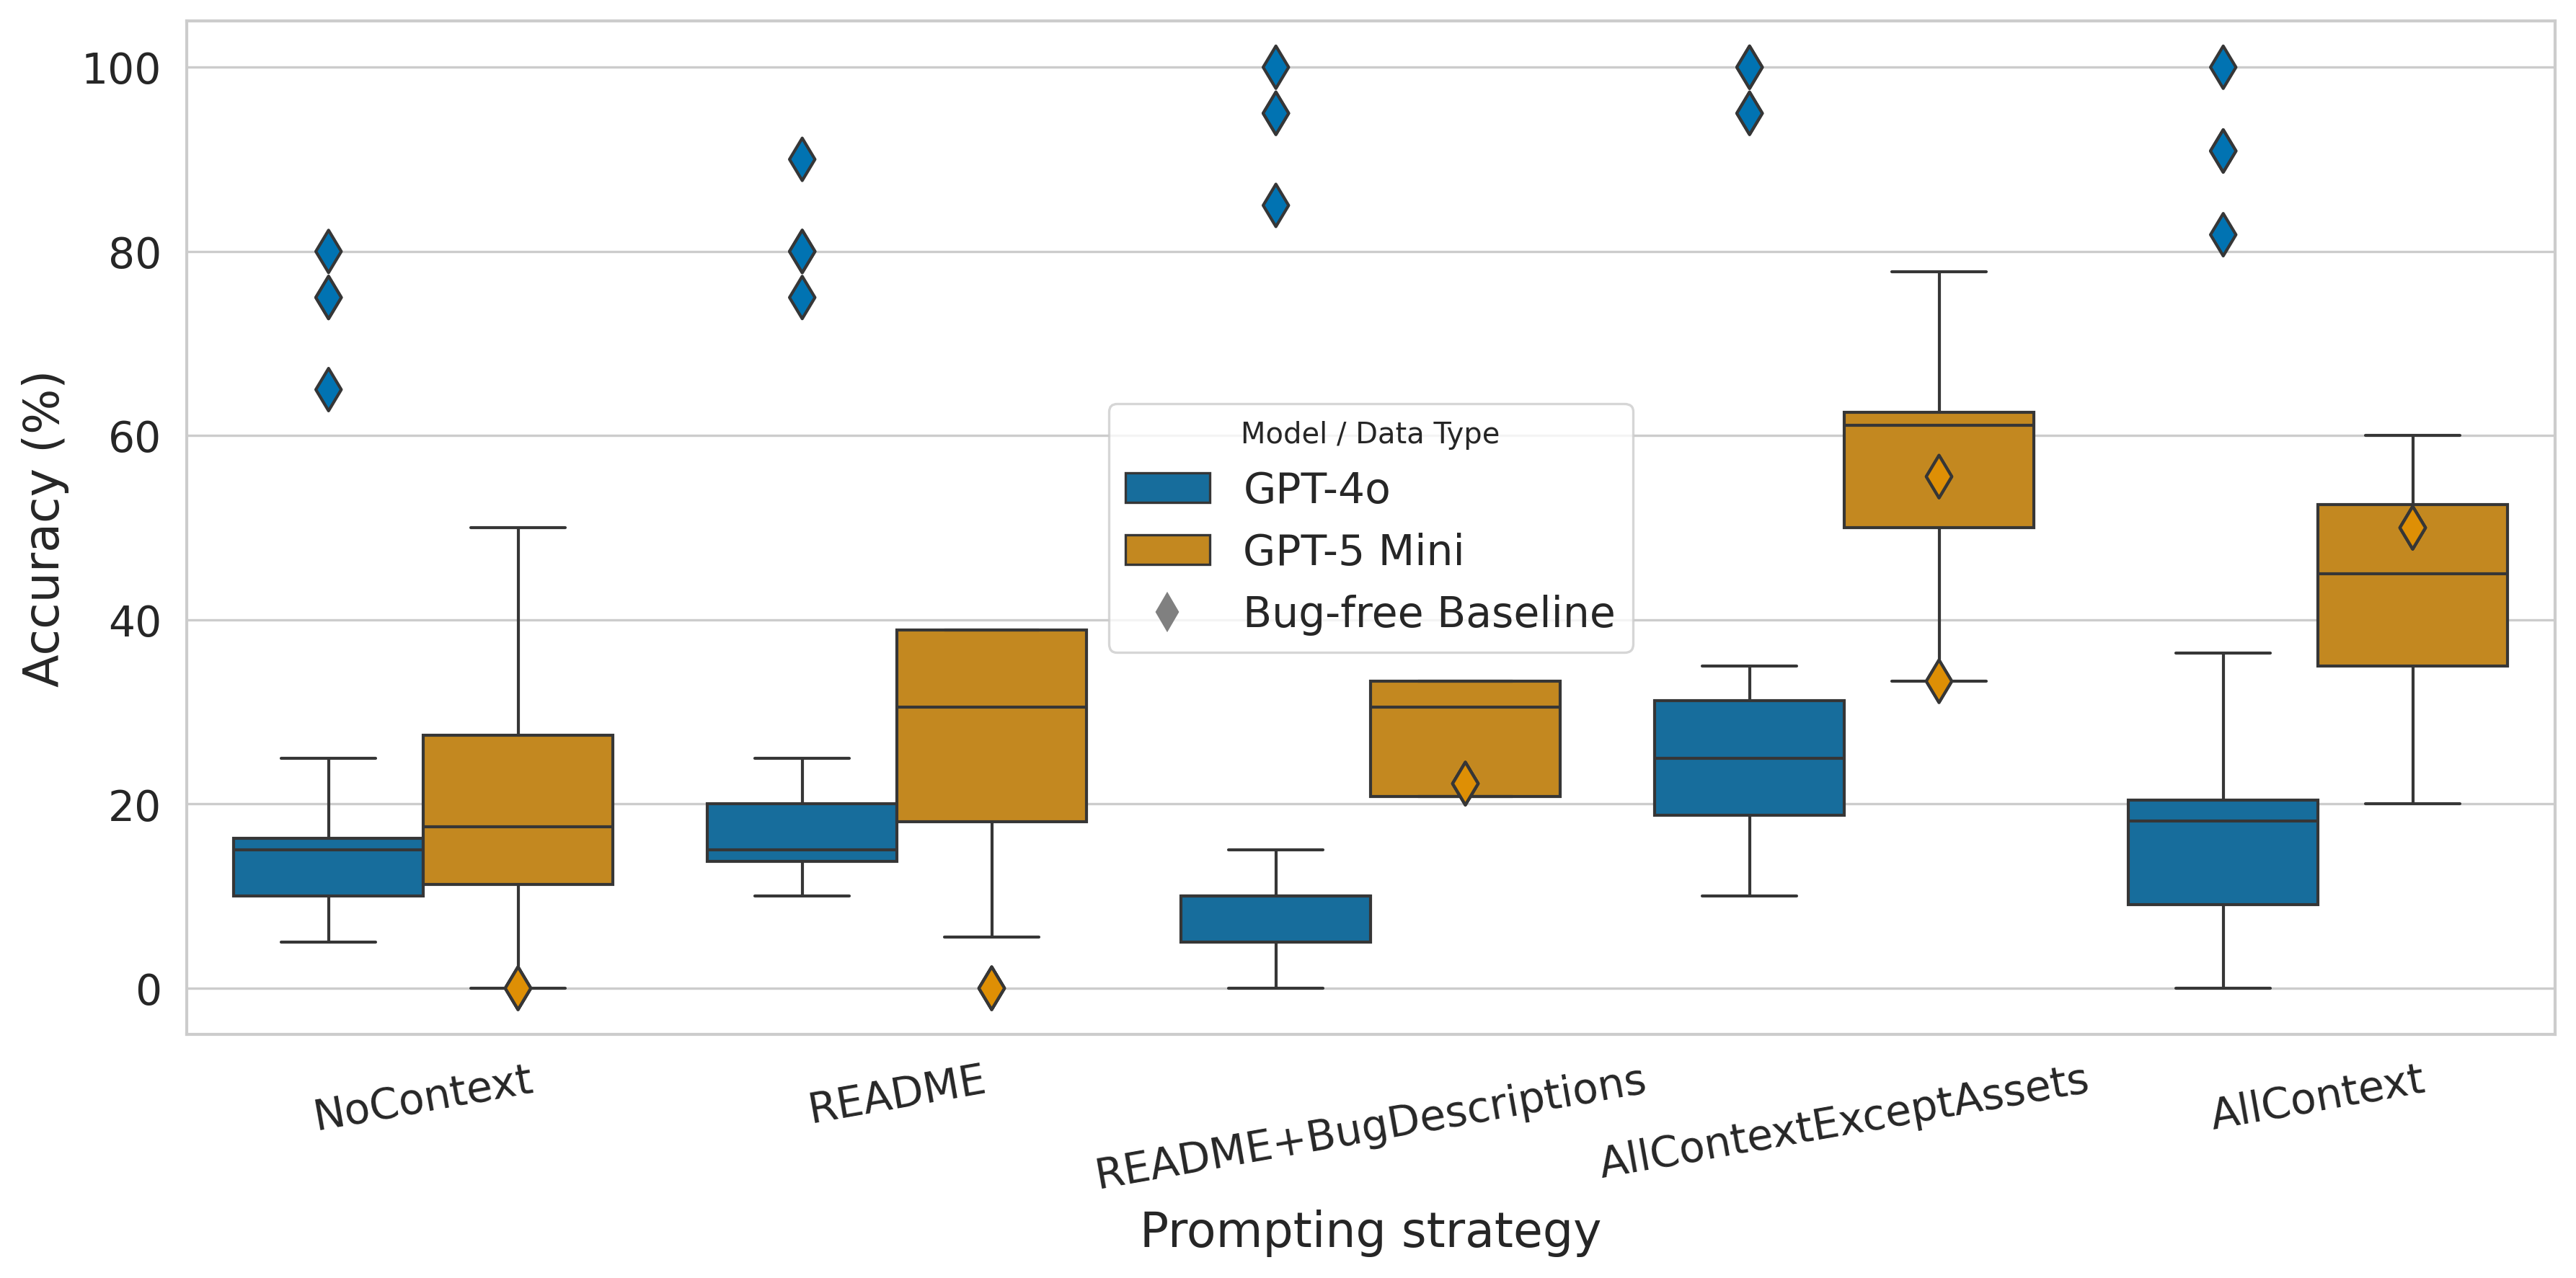

In [80]:
df_metrics_table_for_plotting_gpt_4o = df_metrics_per_sample_gpt_4o.copy(deep=True).explode(["Accuracy", "Precision", "Recall"])[["PromptingStrategy", "Sample", "Accuracy", "Precision", "Recall"]]

df_metrics_table_for_plotting_gpt_4o["Accuracy"] = df_metrics_table_for_plotting_gpt_4o["Accuracy"] * 100
df_metrics_table_for_plotting_gpt_4o["Precision"] = df_metrics_table_for_plotting_gpt_4o["Precision"] * 100
df_metrics_table_for_plotting_gpt_4o["Recall"] = df_metrics_table_for_plotting_gpt_4o["Recall"] * 100


df_metrics_table_for_plotting_gpt_5_mini = df_metrics_per_sample_gpt_5_mini.copy(deep=True).explode(["Accuracy", "Precision", "Recall"])[["PromptingStrategy", "Sample", "Accuracy", "Precision", "Recall"]]

df_metrics_table_for_plotting_gpt_5_mini["Accuracy"] = df_metrics_table_for_plotting_gpt_5_mini["Accuracy"] * 100
df_metrics_table_for_plotting_gpt_5_mini["Precision"] = df_metrics_table_for_plotting_gpt_5_mini["Precision"] * 100
df_metrics_table_for_plotting_gpt_5_mini["Recall"] = df_metrics_table_for_plotting_gpt_5_mini["Recall"] * 100

# 1. Prepare and Combine Data
# Add a 'Model' column to distinguish the datasets
df_metrics_table_for_plotting_gpt_4o["Model"] = "GPT-4o"
df_metrics_table_for_plotting_gpt_5_mini["Model"] = "GPT-5 Mini"

# Combine them into one dataframe
df_combined = pd.concat([
    df_metrics_table_for_plotting_gpt_4o, 
    df_metrics_table_for_plotting_gpt_5_mini
], ignore_index=True)

# Split into "Bug" (for boxplots) and "Clean" (for scatterpoints)
df_bug = df_combined[df_combined["Sample"] != "clean"]
df_clean = df_combined[df_combined["Sample"] == "clean"]

# Setup Plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
sns.set_context("paper")
sns.set_style("whitegrid")

# Define a palette so colors are consistent across both plot types
# Using 'colorblind' with 2 colors for the 2 models
model_palette = sns.color_palette("colorblind", 2) 

# 2. Boxplot (Bug-injected accuracy)
# hue="Model" automatically creates side-by-side boxplots
sns.boxplot(
    data=df_bug,
    x='PromptingStrategy',
    y='Accuracy',
    hue='Model',            # This splits the boxplots
    palette=model_palette,
    ax=ax,
    fliersize=0             # Optional: Hide outliers if you want
)

# 3. Stripplot (Bug-free accuracy)
# We use stripplot instead of scatterplot because it supports 'dodge=True'
sns.stripplot(
    data=df_clean,
    x='PromptingStrategy',
    y='Accuracy',
    hue='Model',            # Necessary for dodge to work
    palette=model_palette,  # Match the boxplot colors
    dodge=True,             # <--- KEY: This aligns the points with the boxplots
    jitter=False,           # Keep points centered (don't scatter them randomly)
    marker="d",             # Diamond shape
    size=10,                # Equivalent to s=100 in scatterplot
    edgecolor="gray",       # Add edge to make them pop
    linewidth=1,
    ax=ax,
    legend=False            # We don't want double legend entries
)

# 4. Customizing the Legend
# Boxplot creates a legend automatically. We need to tweak it to distinguish 
# the boxes (Bug-injected) from the diamonds (Bug-free).
from matplotlib.lines import Line2D

# Get the existing handles/labels (generated by boxplot)
handles, labels = ax.get_legend_handles_labels()

# Create a custom "diamond" handle to represent "Bug-free Baseline"
diamond_marker = Line2D([], [], color='gray', marker='d', linestyle='None',
                        markersize=8, label='Bug-free Baseline')

# Add the diamond to the list of handles
handles.append(diamond_marker)

# Update legend
plt.legend(
    handles=handles, 
    title="Model / Data Type",
    fontsize=FONTSIZE_MED, 
    loc='best' # Adjust location as needed
)

# 5. Labels and Titles
ax.yaxis.set_tick_params(rotation=0, labelsize=FONTSIZE_MED)
ax.xaxis.set_tick_params(rotation=10, labelsize=FONTSIZE_MED)

plt.ylabel("Accuracy (%)", fontsize=FONTSIZE_LARGE)
plt.xlabel("Prompting strategy", fontsize=FONTSIZE_LARGE)

plt.tight_layout()
plt.savefig("results_main-accuracy_per_strategy_combined.pdf", dpi=300, bbox_inches="tight")
# plt.show()

In [76]:
#df_metrics_table_for_plotting[(df_metrics_table_for_plotting["Sample"] != "clean") & (df_metrics_table_for_plotting["PromptingStrategy"] == "AllContext")]

In [77]:
#df_metrics_table_for_plotting.groupby(["PromptingStrategy"])["Precision"].agg("median")

##### Per bug-type with best strategy

<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:23: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:23: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_238445/1270577342.py:22: SyntaxWarning: invalid escape sequence '\i'
  "bug_rendering": "$\it{Rendering}$",
/tmp/ipykernel_238445/1270577342.py:23: SyntaxWarning: invalid escape sequence '\i'
  "bug_appearance": "$\it{Appearance}$",
/tmp/ipykernel_238445/1270577342.py:24: SyntaxWarning: invalid escape sequence '\i'
  "bug_layout": "$\it{Layout}$",
/tmp/ipykernel_238445/1270577342.py:25: SyntaxWarning: invalid escape sequence '\i'
  "bug_state": "$\it{State}$",
/tmp/ipykernel_238445/1270577342.py:22: SyntaxWarning: invalid escape sequence '\i'
  "bug_rendering": "$\it{Ren

NameError: name 'df_metrics_per_sample' is not defined

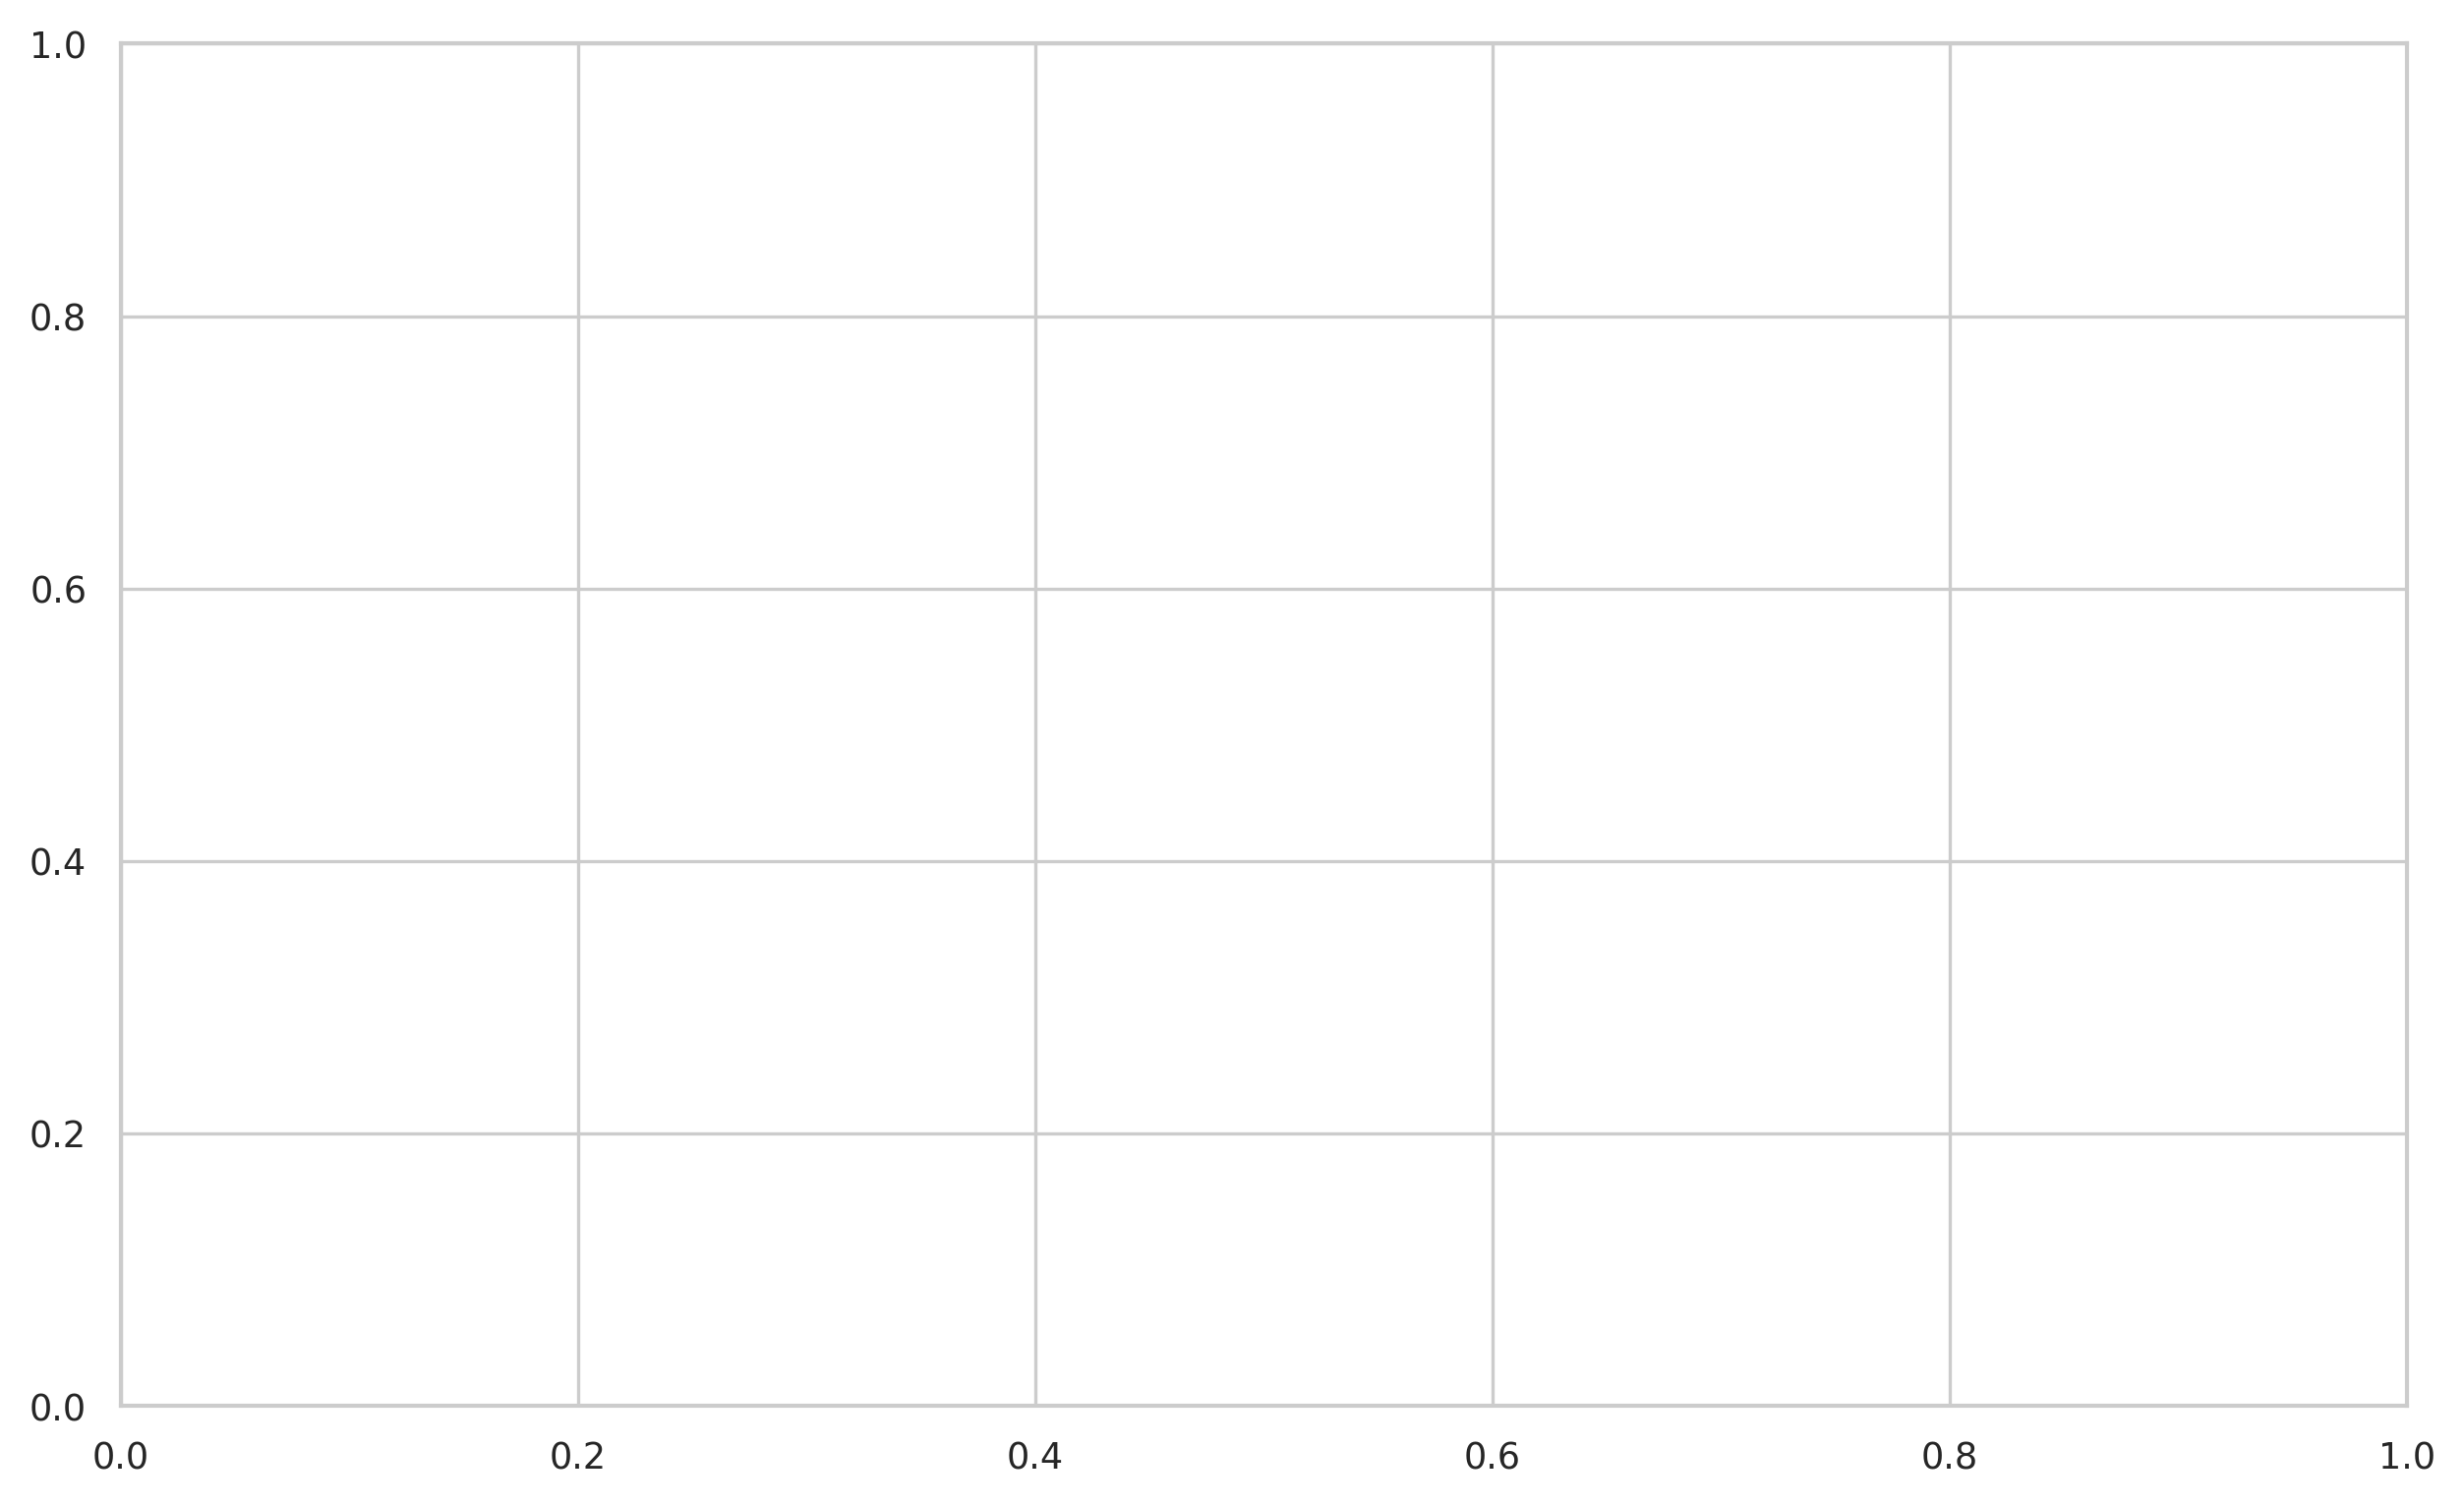

In [78]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

sns.set_context("paper")
sns.set_style("whitegrid")

palette = sns.color_palette("colorblind", 2)

df_metrics_table_for_plotting = df_metrics_per_sample.copy(deep=True).explode(["Accuracy", "Precision", "Recall"])[["PromptingStrategy", "Sample", "Precision", "Recall"]]

df_metrics_table_for_plotting = df_metrics_table_for_plotting[
    (df_metrics_table_for_plotting["PromptingStrategy"] == "AllContextExceptAssets")
    &
    (df_metrics_table_for_plotting["Sample"] != "clean")
]

df_metrics_table_for_plotting["Precision"] = df_metrics_table_for_plotting["Precision"] * 100
df_metrics_table_for_plotting["Recall"] = df_metrics_table_for_plotting["Recall"] * 100


df_metrics_table_for_plotting["Sample"] = df_metrics_table_for_plotting["Sample"].map(
    {
        "bug_rendering": "$\it{Rendering}$",
        "bug_appearance": "$\it{Appearance}$",
        "bug_layout": "$\it{Layout}$",
        "bug_state": "$\it{State}$",
    }
)

# ... (Previous code for palette and dataframe setup remains the same)

x_categories = df_metrics_table_for_plotting['Sample'].unique()

# [NEW] 1. Create a mapping from category name to integer index (0, 1, 2...)
# This allows us to perform math on the x-coordinates.
cat_to_num = {category: i for i, category in enumerate(x_categories)}
df_metrics_table_for_plotting['Sample_Num'] = df_metrics_table_for_plotting['Sample'].map(cat_to_num)

# --- Plotting Ranges (Your existing loop) ---
for i, app in enumerate(x_categories):
    subset = df_metrics_table_for_plotting[df_metrics_table_for_plotting['Sample'] == app]
    
    # Precision Range (Offset -0.1)
    y_min_p = subset['Precision'].min()
    y_max_p = subset['Precision'].max()
    ax.fill_betweenx(
        y=[y_min_p, y_max_p],
        x1=i - 0.1 - 0.025, 
        x2=i - 0.1 + 0.025,
        color=palette[0] + (0.3, ),
        edgecolor=palette[0] + (0.8, ),
        label="Range of precision" if i == 0 else None
    )

    # Recall Range (Offset +0.1)
    y_min_r = subset['Recall'].min()
    y_max_r = subset['Recall'].max()
    ax.fill_betweenx(
        y=[y_min_r, y_max_r],
        x1=i + 0.1 - 0.025,
        x2=i + 0.1 + 0.025,
        color=palette[1] + (0.3, ),
        edgecolor=palette[1] + (0.8, ),
        label="Range of recall" if i == 0 else None
    )

# --- Plotting Scatter Points ---

# Precision Scatter: Use the numeric column and subtract 0.1
sns.scatterplot(
    data=df_metrics_table_for_plotting,
    x=df_metrics_table_for_plotting['Sample_Num'] - 0.1, # [NEW] Manual offset
    y='Precision',
    ax=ax,
    color=palette[0] + (0.6, ),
    markers=True,
    marker="d",
    s=100,
    edgecolor=(0.2, 0.2, 0.2, 0.5),
    label="Precision yielded by each repetition"
)

# Recall Scatter: Use the numeric column and add 0.1
sns.scatterplot(
    data=df_metrics_table_for_plotting,
    x=df_metrics_table_for_plotting['Sample_Num'] + 0.1, # [NEW] Manual offset
    y='Recall',
    ax=ax,
    color=palette[1] + (0.6, ),
    markers=True,
    marker="o",
    s=100,
    edgecolor=(0.2, 0.2, 0.2, 0.5),
    label="Recall yielded by each repetition"
)

# [NEW] Since we plotted numbers on X, we must manually ensure the labels are correct
ax.set_xticks(range(len(x_categories)))
ax.set_xticklabels(x_categories)

# ... (Rest of your styling code: tick_params, legends, labels, etc.)

ax.yaxis.set_tick_params(labelsize=FONTSIZE_MED)
ax.xaxis.set_tick_params(rotation=10, labelsize=FONTSIZE_MED)
plt.legend(fontsize=FONTSIZE_MED)
plt.ylabel("Precision (%) and recall (%)", fontsize=FONTSIZE_LARGE)
plt.xlabel("Visual bug type", fontsize=FONTSIZE_LARGE)
plt.tight_layout()
# plt.show()
plt.savefig("results_main-precision_and_recall_per_bugtype.pdf", dpi=300, bbox_inches="tight")

In [ ]:
df_metrics_per_sample.explode(["Accuracy", "Precision", "Recall"]).groupby(["PromptingStrategy", "Sample"])["Recall"].agg(["mean", "std", "max", "min", "count", "median"])

#### Per-app

In [ ]:
# df_metrics_per_app["AppName"].isna().any()  # double check

In [ ]:
df_metrics_table_for_plotting.sort_values(by=["AppName", "PromptingStrategy"])

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

sns.set_context("paper")
sns.set_style("whitegrid")

palette = sns.color_palette("Greys", 1)

df_metrics_table_for_plotting = df_metrics_per_app.copy(deep=True).explode(["Accuracy", "Precision", "Recall"])[["PromptingStrategy", "AppName", "Accuracy"]]

df_metrics_table_for_plotting = df_metrics_table_for_plotting[
    (df_metrics_table_for_plotting["PromptingStrategy"] == "AllContextExceptAssets")
]

df_metrics_table_for_plotting["Accuracy"] = df_metrics_table_for_plotting["Accuracy"] * 100
df_metrics_table_for_plotting["AppName"] = df_metrics_table_for_plotting["AppName"].astype(type_app_name)
df_metrics_table_for_plotting = df_metrics_table_for_plotting.sort_values(by="AppName")
x_categories = df_metrics_table_for_plotting["AppName"].unique()

for i, app in enumerate(x_categories):
    subset = df_metrics_table_for_plotting[df_metrics_table_for_plotting['AppName'] == app]
    y_min = subset['Accuracy'].min()
    y_max = subset['Accuracy'].max()

    # Use fill_between to create a vertical cloud
    ax.fill_betweenx(
        y=[y_min, y_max],     # Range of y-values
        x1=i - 0.1625,           # Start of the cloud (slightly offset for width)
        x2=i + 0.1625,           # End of the cloud
        color=palette[0] + (0.3, ),
        edgecolor=(0.2, 0.2, 0.2),
        # alpha=0.2,
        label="Range of accuracy yielded across 4 repetitions" if i == 0 else None
    )

sns.scatterplot(
    data=df_metrics_table_for_plotting,
    x='AppName',
    y='Accuracy',
    # hue='Sample',
    ax=ax,
    color=palette[0] + (0.3, ),
    markers=True,
    marker="o",
    s=100,
    # dashes=None,
    # style=
    edgecolor="black",
    label="Accuracy yielded by each repetition"
)

# ax.grid(False, which="major", axis="x")
# ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.7)
ax.yaxis.set_tick_params(labelsize=FONTSIZE_MED)
ax.xaxis.set_tick_params(rotation=90, labelsize=FONTSIZE_MED)
plt.legend(fontsize=FONTSIZE_MED)
plt.ylabel("Accuracy (%)", fontsize=FONTSIZE_LARGE)
plt.xlabel("Application", fontsize=FONTSIZE_LARGE)
# plt.tight_layout()
# plt.show()
plt.savefig("results_main-accuracy_per_app.pdf", dpi=300, bbox_inches="tight")

#### pass@k -- (skip, plot isn't very meaningful, table is better)

In [ ]:
# melted_df = df_pass_at_k.melt(
#     id_vars=['PromptingStrategy', 'Sample', 'AppName'],
#     value_vars=['Pass@1', 'Pass@2', 'Pass@3', 'Pass@4'],
#     var_name='PassMetric',
#     value_name='Value'
# )

# melted_df['k'] = melted_df['PassMetric'].str.extract('(\d+)').astype(int)

# # Group by PromptingStrategy and k, and calculate mean, min, and max
# # grouped = melted_df.groupby(['PromptingStrategy', 'k'])['Value'].agg(['mean', 'min', 'max']).reset_index()
# grouped = melted_df.groupby(['PromptingStrategy', 'k'])['Value'].agg(['mean', 'std']).reset_index()

# # Plot
# plt.figure(figsize=(10, 6))
# for strategy, data in grouped.groupby('PromptingStrategy'):
#     plt.plot(data['k'], data['mean'], marker='o', label=f'{strategy} (Mean)')
#     # plt.fill_between(data['k'], data['min'], data['max'], alpha=0.2, label=f'{strategy} (Min-Max)')
#     plt.fill_between(data['k'],
#                  data['mean'] - data['std'],
#                  data['mean'] + data['std'],
#                 alpha=0.2, label=f'{strategy} (Std Dev)')

# # Formatting
# plt.title('Pass@k by Prompting Strategy')
# plt.xlabel('Pass@k')
# plt.ylabel('Value')
# plt.xticks(grouped['k'].unique(), labels=[f'Pass@{k}' for k in grouped['k'].unique()])
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

# plt.show()


### Per-app results -- Differences across prompting strategies

#### Look at per-app differences in metrics -- for ablation study (see `./Ablation.ipynb`)


In [ ]:
# df_metrics_per_app[df_metrics_per_app["PromptingStrategy"] == "NoContext"].groupby("AppName").count()

In [ ]:
# df_metrics_per_app[(df_metrics_per_app["PromptingStrategy"] == "NoContext") & (df_metrics_per_app["AppName"] == "dimforge-rapier.js")]

In [ ]:
# df_results_compiled[(df_results_compiled["TextAppName"] == "dimforge-rapier.js") & (df_results_compiled["IntRunNumber"] == 5)] # & (df_results_compiled[])]

In [ ]:
# df_results_compiled[(df_results_compiled["TextAppName"] == "chase-manning-react-photo-studio") & (df_results_compiled["IntRunNumber"] == 2)] # & (df_results_compiled[])]

In [ ]:
# df_metrics_per_app[df_metrics_per_app["PromptingStrategy"] == "NoContext"].groupby("AppName").count()
# # df_metrics_per_app[df_metrics_per_app["PromptingStrategy"] == "NoContext" & df_metrics_per_app["Recall"].isna()].groupby("AppName").count()

# df_metrics_per_app[(df_metrics_per_app["PromptingStrategy"] == "NoContext") & (df_metrics_per_app["AppName"] == "chase-manning-react-photo-studio")]

In [ ]:
def get_average_metric_values_per_strategy(
        df_in,
        name_of_strategy="NoContext",
        name_of_metric="Recall"
    ):
    return df_in[df_in["PromptingStrategy"] == name_of_strategy].sort_values(
        by=["AppName", "Iteration"]
    ).reset_index(
        drop=True
    ).groupby(
        "AppName"
    )[name_of_metric].mean()

vals_recall_nocontext = get_average_metric_values_per_strategy(df_metrics_per_app, "NoContext", "Recall")
vals_precision_nocontext = get_average_metric_values_per_strategy(df_metrics_per_app, "NoContext", "Precision")

vals_recall_readme = get_average_metric_values_per_strategy(df_metrics_per_app, "README", "Recall")
vals_precision_readme = get_average_metric_values_per_strategy(df_metrics_per_app, "README", "Precision")

(vals_recall_readme - vals_recall_nocontext).sort_values(ascending=False)

# vals_precision_readme - vals_precision_nocontext

Top 3 positive mean recall diffs (applications) when using README as context:
1. `VoiceSpaceUnder5-VoiceSpace      (+0.29)`
2. `chase-manning-react-photo-studio (+0.17)`
3. `starwards-starwards              (+0.13)`

Bottom 3 negative mean recall diffs (applications) when using README as context:
1. `ha-shine-wasm-tetris         (-0.27)`
2. `higlass-higlass              (-0.21)`
3. `p5aholic-playground          (-0.13)`

--> Use these applications in the Ablation study (see experiments in `../2-Experiments/run_ablation.sh` and results in `./Ablation.ipynb`)

### Calculate README lengths

In [ ]:
def read_file_and_count_tokens(path_to_file):
    # read file
    with open(path_to_file, "r") as f:
        content = f.read()

        # count tokens with tiktoken (gpt-4o tokenizer)
        encoding = tiktoken.encoding_for_model("gpt-4o-2024-08-06")
        tokens = encoding.encode(content)

    return len(tokens)

In [ ]:
path_to_external_repos = Path("../../vlm_canvas_bugs-external_repos/")

dict_num_tokens_original_readmes = {}

for path_to_repo in [ptr for ptr in path_to_external_repos.iterdir() if ptr.is_dir()]:

    name_of_app = path_to_repo.name

    if name_of_app not in app_names:
        continue

    print(f"Processing {name_of_app}...")

    dict_num_tokens_original_readmes[name_of_app] = 0

    for path_to_file in path_to_repo.resolve().rglob("README.md"):

        if "node_modules" in str(path_to_file):
            continue

        # print(f"    Found README.md at {path_to_file}")
        num_tokens = read_file_and_count_tokens(path_to_file)
        dict_num_tokens_original_readmes[name_of_app] += num_tokens

dict_num_tokens_rounded_original_readmes = {}

for key in dict_num_tokens_original_readmes.keys():
    dict_num_tokens_rounded_original_readmes[key] =  np.round(dict_num_tokens_original_readmes[key], -1)

dict_num_tokens_rounded_original_readmes

In [ ]:
(df_tokens_per_app_readme_original := pd.DataFrame.from_dict(
    dict_num_tokens_rounded_original_readmes,
    orient="index"
).sort_values(
    by=0,
    ascending=False
).rename(
    {0: "NumTokensInREADMEs"},
    axis=1)
)

In [ ]:
path_to_ablated_readmes = Path("../Data/2-Experiments/ablated_readmes/")

dict_num_tokens_ablated_readmes = {}

for path_to_file in path_to_ablated_readmes.glob("informative/**/README.md"):
    num_tokens = read_file_and_count_tokens(path_to_file)
    dict_num_tokens_ablated_readmes[f"{path_to_file.parent.name}(GOOD)"] = num_tokens


for path_to_file in path_to_ablated_readmes.glob("distracting/**/README.md"):
    num_tokens = read_file_and_count_tokens(path_to_file)
    dict_num_tokens_ablated_readmes[f"{path_to_file.parent.name}(BAD)"] = num_tokens

dict_num_tokens_ablated_readmes_rounded = {}

for key in dict_num_tokens_ablated_readmes.keys():
    dict_num_tokens_ablated_readmes_rounded[key] = np.round(dict_num_tokens_ablated_readmes[key], -1)


In [ ]:
(df_tokens_per_app_readme_ablated := pd.DataFrame.from_dict(
    dict_num_tokens_ablated_readmes_rounded,
    orient="index"
).sort_values(
    by=0,
    ascending=False
).rename(
    {0: "NumTokensInREADMEs"},
    axis=1)
)

In [ ]:
(df_tokens_per_app_readme := pd.concat([df_tokens_per_app_readme_original, df_tokens_per_app_readme_ablated]).sort_index())

In [ ]:
print("Max of original READMEs")
df_tokens_per_app_readme_original.max()

In [ ]:
print("Min of original READMEs")
df_tokens_per_app_readme_original.min()

--> original READMEs length supplied per app ranges from 130 to 2420 tokens.

In [ ]:
print("Max of ablated READMEs")
df_tokens_per_app_readme_ablated.max()

In [ ]:
print("Min of ablated READMEs")
df_tokens_per_app_readme_ablated.min()

--> ablated READMEs length supplied per app ranges from 0 to 2320 tokens.